# Fast-SCNN - Cityscapes Dataset

Treinamento do Fast-SCNN usando o dataset Cityscapes completo.

In [ ]:
# Importação das bibliotecas principais
import torch

In [ ]:
# Dataset ULTRA-OTIMIZADO (sem conversão RGB->trainID, usa CrossEntropyLoss direto)
import os
import numpy as np
from torch.utils.data import Dataset, DataLoader
from PIL import Image

class CityscapesDatasetFast(Dataset):
    def __init__(self, cityscapes_root, split='train', img_height=256, img_width=512, max_samples=None):
        self.cityscapes_root = cityscapes_root
        self.split = split
        self.img_height = img_height
        self.img_width = img_width
        
        # Caminhos
        self.img_dir = os.path.join(cityscapes_root, 'leftImg8bit', split)
        self.gtfine_dir = os.path.join(cityscapes_root, 'gtFine', split)
        
        # Coleta imagens
        self.images = []
        
        self.annotations = []
        count = 0
        for city in sorted(os.listdir(self.img_dir)):
            city_img_dir = os.path.join(self.img_dir, city)
            city_gtfine_dir = os.path.join(self.gtfine_dir, city)
            
            if not os.path.isdir(city_img_dir):
                continue
            
            for img_file in sorted(os.listdir(city_img_dir)):
                if img_file.endswith('_leftImg8bit.png'):
                    img_path = os.path.join(city_img_dir, img_file)
                    base_name = img_file.replace('_leftImg8bit.png', '')
                    gtfine_file = f'{base_name}_gtFine_color.png'
                    gtfine_path = os.path.join(city_gtfine_dir, gtfine_file)
                    
                    if os.path.exists(gtfine_path):
                        self.images.append(img_path)
                        self.annotations.append(gtfine_path)
                        count += 1
                        if max_samples and count >= max_samples:
                            break
            if max_samples and count >= max_samples:
                break
        print(f'Dataset {split}: {len(self.images)} imagens')
        self.lut = self._create_lut()
    def _create_lut(self):
        lut = np.full((256, 256, 256), 255, dtype=np.uint8)
        colors = {
            (128, 64, 128): 0, (244, 35, 232): 1, (70, 70, 70): 2, (102, 102, 156): 3,
            (190, 153, 153): 4, (153, 153, 153): 5, (250, 170, 30): 6, (220, 220, 0): 7,
            (107, 142, 35): 8, (152, 251, 152): 9, (70, 130, 180): 10, (220, 20, 60): 11,
            (255, 0, 0): 12, (0, 0, 142): 13, (0, 0, 70): 14, (0, 60, 100): 15,
            (0, 80, 100): 16, (0, 0, 230): 17, (119, 11, 32): 18
        }
        
        for (r, g, b), train_id in colors.items():
            lut[r, g, b] = train_id
        
        return lut
    
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        # Carrega imagem
        img = Image.open(self.images[idx]).convert('RGB')
        img = img.resize((512, 256), Image.BILINEAR)
        img = np.array(img, dtype=np.float32) / 255.0
        
        # Carrega máscara
        mask = Image.open(self.annotations[idx]).convert('RGB')
        mask = mask.resize((512, 256), Image.NEAREST)
        mask_rgb = np.array(mask, dtype=np.uint8)
        
        # Conversão RÁPIDA usando LUT
        trainid_mask = self.lut[mask_rgb[:,:,0], mask_rgb[:,:,1], mask_rgb[:,:,2]]
        
        # Converte para tensores
        img_tensor = torch.from_numpy(img).permute(2, 0, 1).float()
        mask_tensor = torch.from_numpy(trainid_mask).long()
        
        return img_tensor, mask_tensor

# Caminho para o Cityscapes
cityscapes_root = r'd:\Documentos\Git\edge-segmentation-lab\city'

train_dataset = CityscapesDatasetFast(cityscapes_root, split='train', img_height=256, img_width=512, max_samples=2000)

# Dataloader
train_loader = DataLoader(
    train_dataset, 
    batch_size=4,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

print(f'\n⚡ Configuração otimizada:')
print(f'Dataset: {len(train_dataset)} imagens, {len(train_loader)} batches')
print(f'Resolução: 512x256')
print(f'Batch size: 4')

In [ ]:
# Loss simplificada (CrossEntropyLoss já funciona com trainIDs)
import torch.nn as nn

criterion = nn.CrossEntropyLoss(ignore_index=255)

## Treinamento

In [ ]:
# Configuração GPU (preferencial)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if device.type == 'cuda':
    print(f'Usando GPU: {torch.cuda.get_device_name(0)}')
    print(f'Memória disponível: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB')
    print(f'Memória alocada: {torch.cuda.memory_allocated(0) / 1e9:.2f} GB')
else:
    print('Usando CPU para treinamento.')

In [ ]:
# Importar modelo Fast-SCNN
import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', 'src', 'models')))
from fast_scnn import FastSCNN

# Criar modelo
model = FastSCNN(num_classes=19, aux=False).to(device)
print(f'Modelo FastSCNN criado com {sum(p.numel() for p in model.parameters())/1e6:.2f}M parâmetros')

# Optimizer e Scheduler
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

In [ ]:
# Treinamento Fast-SCNN simplificado
import time
num_epochs = 10
best_loss = float('inf')
start_time = time.time()
print(f'Treinando por {num_epochs} épocas com {len(train_loader.dataset)} imagens...')
for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    for imgs, masks in train_loader:
        imgs, masks = imgs.to(device), masks.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)[0]
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    avg_train_loss = train_loss / len(train_loader)
    scheduler.step(avg_train_loss)
    if avg_train_loss < best_loss:
        best_loss = avg_train_loss
        torch.save(model.state_dict(), 'fastscnn_best.pth')
        print(f'Epoca {epoch+1}/{num_epochs} | Loss: {avg_train_loss:.4f} ⭐')
    else:
        print(f'Epoca {epoch+1}/{num_epochs} | Loss: {avg_train_loss:.4f}')
print(f'Treinamento concluido em {((time.time()-start_time)/60):.1f} min | Melhor Loss: {best_loss:.4f}')

Epoca 1/15 | Loss: 0.7112 ⭐
Epoca 2/15 | Loss: 0.5260 ⭐
Epoca 2/15 | Loss: 0.5260 ⭐
Epoca 3/15 | Loss: 0.4647 ⭐
Epoca 3/15 | Loss: 0.4647 ⭐
Epoca 4/15 | Loss: 0.4306 ⭐
Epoca 4/15 | Loss: 0.4306 ⭐
Epoca 5/15 | Loss: 0.3979 ⭐
Epoca 5/15 | Loss: 0.3979 ⭐
Epoca 6/15 | Loss: 0.3788 ⭐
Epoca 6/15 | Loss: 0.3788 ⭐
Epoca 7/15 | Loss: 0.3554 ⭐
Epoca 7/15 | Loss: 0.3554 ⭐
Epoca 8/15 | Loss: 0.3518 ⭐
Epoca 8/15 | Loss: 0.3518 ⭐
Epoca 9/15 | Loss: 0.3420 ⭐
Epoca 9/15 | Loss: 0.3420 ⭐
Epoca 10/15 | Loss: 0.3225 ⭐
Epoca 10/15 | Loss: 0.3225 ⭐
Epoca 11/15 | Loss: 0.3135 ⭐
Epoca 11/15 | Loss: 0.3135 ⭐
Epoca 12/15 | Loss: 0.3040 ⭐
Epoca 12/15 | Loss: 0.3040 ⭐
Epoca 13/15 | Loss: 0.2903 ⭐
Epoca 13/15 | Loss: 0.2903 ⭐
Epoca 14/15 | Loss: 0.2833 ⭐
Epoca 14/15 | Loss: 0.2833 ⭐


## Teste com Imagem Específica (Bielefeld)

Erro ao rodar predição: name 'model' is not defined


Erro ao rodar predição: name 'model' is not defined


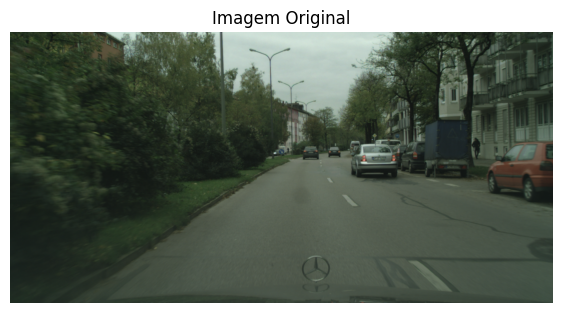

In [1]:
import matplotlib.pyplot as plt
import torch
from PIL import Image
import numpy as np

# Teste com imagem SEM máscara
test_img_path = r'D:\Documentos\Git\edge-segmentation-lab\city\leftImg8bit\test\munich\munich_000390_000019_leftImg8bit.png'

# Processar imagem (mesma resolução do treinamento)
img = Image.open(test_img_path).convert('RGB')
img_resized = img.resize((1024, 512))
img_np = np.array(img_resized, dtype=np.float32) / 255.0

# Predição do modelo (se treinado)
try:
    model.eval()
    with torch.no_grad():
        img_tensor = torch.from_numpy(img_np).permute(2, 0, 1).unsqueeze(0).float().to(device)
        pred = model(img_tensor)[0]
        pred_mask = torch.argmax(pred, dim=1).squeeze().cpu().numpy()
        h, w = pred_mask.shape
        # Paleta de cores para visualização
        cityscapes_palette = [
            (128, 64, 128), (244, 35, 232), (70, 70, 70), (102, 102, 156),
            (190, 153, 153), (153, 153, 153), (250, 170, 30), (220, 220, 0),
            (107, 142, 35), (152, 251, 152), (70, 130, 180), (220, 20, 60),
            (255, 0, 0), (0, 0, 142), (0, 0, 70), (0, 60, 100),
            (0, 80, 100), (0, 0, 230), (119, 11, 32)
        ]
        pred_colored = np.zeros((h, w, 3), dtype=np.uint8)
        for class_id, color in enumerate(cityscapes_palette):
            pred_colored[pred_mask == class_id] = color
        fig, axes = plt.subplots(1, 2, figsize=(14, 6))
        axes[0].imshow(img_resized)
        axes[0].set_title('Imagem Original', fontsize=12)
        axes[0].axis('off')
        axes[1].imshow(pred_colored)
        axes[1].set_title('Predição do Modelo', fontsize=12)
        axes[1].axis('off')
        plt.tight_layout()
        plt.show()
except Exception as e:
    print('Erro ao rodar predição:', e)
    fig, ax = plt.subplots(figsize=(7, 6))
    ax.imshow(img_resized)
    ax.set_title('Imagem Original', fontsize=12)
    ax.axis('off')
    plt.show()

In [ ]:
# Avaliação automática em 5 imagens de Munique (sem máscara ground truth)
import glob
munich_dir = r'D:\Documentos\Git\edge-segmentation-lab\city\leftImg8bit\test\munich'
munich_imgs = sorted(glob.glob(os.path.join(munich_dir, '*_leftImg8bit.png')))[:5]
print(f'Avaliando {len(munich_imgs)} imagens de Munique...')
for img_path in munich_imgs:
    img = Image.open(img_path).convert('RGB').resize((512, 256))
    img_np = np.array(img, dtype=np.float32) / 255.0
    model.eval()
    with torch.no_grad():
        img_tensor = torch.from_numpy(img_np).permute(2, 0, 1).unsqueeze(0).float().to(device)
        pred = model(img_tensor)[0]
        pred_mask = torch.argmax(pred, dim=1).squeeze().cpu().numpy()
        h, w = pred_mask.shape
        cityscapes_palette = [
            (128, 64, 128), (244, 35, 232), (70, 70, 70), (102, 102, 156),
            (190, 153, 153), (153, 153, 153), (250, 170, 30), (220, 220, 0),
            (107, 142, 35), (152, 251, 152), (70, 130, 180), (220, 20, 60),
            (255, 0, 0), (0, 0, 142), (0, 0, 70), (0, 60, 100),
            (0, 80, 100), (0, 0, 230), (119, 11, 32)
        ]
        pred_colored = np.zeros((h, w, 3), dtype=np.uint8)
        for class_id, color in enumerate(cityscapes_palette):
            pred_colored[pred_mask == class_id] = color
        fig, axes = plt.subplots(1, 2, figsize=(14, 6))
        axes[0].imshow(img)
        axes[0].set_title(f'Imagem Original\n{os.path.basename(img_path)}', fontsize=12)
        axes[0].axis('off')
        axes[1].imshow(pred_colored)
        axes[1].set_title('Predição do Modelo', fontsize=12)
        axes[1].axis('off')
        plt.tight_layout()
        plt.show()